# CNN( Convolutionnal Neuronal Network)

In [14]:
#Installation de la bibliothèque TensorFlow 

%pip install tensorflow
print("Installation terminée ")

Installation terminée 



In [15]:
import tensorflow as tf 
print(tf.__version__)


2.21.0


### Préparation des images au traitement CNN

In [16]:
import pandas as pd

df_split = pd.read_csv(r"C:\Users\DELL\PneumoScan\data\split.csv")

train_paths = df_split[df_split["split"] == "train"]["path"].values
val_paths = df_split[df_split["split"] == "val"]["path"].values
test_paths = df_split[df_split["split"] == "test"]["path"].values

train_labels = df_split[df_split["split"] == "train"]["label"].values
val_labels = df_split[df_split["split"] == "val"]["label"].values
test_labels = df_split[df_split["split"] == "test"]["label"].values

print(len(train_paths), len(val_paths), len(test_paths))

4252 724 880


In [17]:
y_train = (train_labels == "PNEUMONIA").astype(int)
y_val = (val_labels == "PNEUMONIA").astype(int)
y_test = (test_labels == "PNEUMONIA").astype(int)

In [18]:
%%time
import numpy as np 
from PIL import Image 

def preprocess_images_cnn(paths , size=(128 , 128 )):
    images = [] 
    for p in paths : 
        image = Image.open(p).convert('L')
        img = image.resize(size)
        arr = np.array(img , dtype=np.float32 )/255 
        arr = np.expand_dims(arr , axis=-1)
        images.append(arr)
    return np.array(images)

X_train_cnn = preprocess_images_cnn(train_paths)
X_val_cnn = preprocess_images_cnn(val_paths)
X_test_cnn = preprocess_images_cnn(test_paths)

print(X_train_cnn.shape , X_val_cnn.shape , X_test_cnn.shape )



(4252, 128, 128, 1) (724, 128, 128, 1) (880, 128, 128, 1)
CPU times: total: 1min 56s
Wall time: 2min 5s


### Construction de l'architecture CNN 


In [19]:
%%time
from tensorflow.keras import layers , models 

model_cnn = models.Sequential([
    layers.Input(shape=(128 , 128 , 1)),

    layers.Conv2D(32 , (3 , 3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid"),
    
])

model_cnn.compile(
    optimizer="adam",
    loss = "binary_crossentropy", 
    metrics = ['accuracy']
    
)

model_cnn.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)                    │ (None, 126, 126, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

CPU times: total: 266 ms
Wall time: 187 ms


### Entrainement du modèle 

In [20]:
%%time
import numpy as np 
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping 

early_stop = EarlyStopping(
    monitor = 'val_loss' ,
    patience = 3 , 
    restore_best_weights = True
)

class_weights = compute_class_weight('balanced' , classes = np.unique(y_train) , y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

history = model_cnn.fit(
    X_train_cnn , y_train, 
    validation_data = (X_val_cnn , y_val), 
    epochs = 10 , 
    batch_size = 32 , 
    class_weight=class_weight_dict, 
    callbacks = [early_stop]
)

{0: np.float64(1.9016100178890876), 1: np.float64(0.6783663050414805)}
Epoch 1/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 38s 248ms/step - accuracy: 0.8140 - loss: 0.3930 - val_accuracy: 0.8867 - val_loss: 0.2663
Epoch 2/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 33s 245ms/step - accuracy: 0.9179 - loss: 0.2036 - val_accuracy: 0.9323 - val_loss: 0.1830
Epoch 3/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 32s 238ms/step - accuracy: 0.9316 - loss: 0.1859 - val_accuracy: 0.9378 - val_loss: 0.1700
Epoch 4/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 31s 235ms/step - accuracy: 0.9370 - loss: 0.1573 - val_accuracy: 0.9461 - val_loss: 0.1400
Epoch 5/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 31s 234ms/step - accuracy: 0.9443 - loss: 0.1462 - val_accuracy: 0.9130 - val_loss: 0.2024
Epoch 6/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 31s 234ms/step - accuracy: 0.9513 - loss: 0.1254 - val_accuracy: 0.9448 - val_loss: 0.1488
Epoch 7/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 33s 251ms/step - accuracy: 0.9539 - loss: 0.1246 - val_accuracy: 0.9337 - val_loss: 0.1806
CPU times: t

In [21]:
from sklearn.metrics import accuracy_score , precision_score , roc_auc_score , recall_score , confusion_matrix

y_proba_cnn = model_cnn.predict(X_val_cnn).ravel()
y_pred_cnn = (y_proba_cnn >= 0.25 ).astype(int)


print("Accuracy :", accuracy_score(y_val, y_pred_cnn))
print("Precision :", precision_score(y_val, y_pred_cnn))
print("Recall :", recall_score(y_val, y_pred_cnn))
print("ROC-AUC :", roc_auc_score(y_val, y_proba_cnn))
print("Matrice de confusion :\n", confusion_matrix(y_val, y_pred_cnn))



23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step 
Accuracy : 0.9419889502762431
Precision : 0.9315315315315316
Recall : 0.9923224568138196
ROC-AUC : 0.9851082136474949
Matrice de confusion :
 [[165  38]
 [  4 517]]


## Calcul de recall et précisions à tous les seuils 

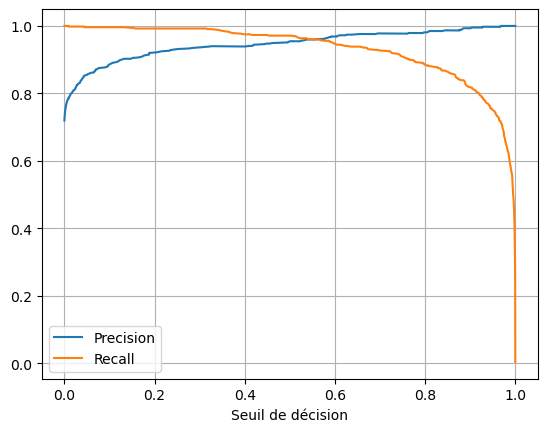

CPU times: total: 250 ms
Wall time: 305 ms


In [23]:
%%time
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt 

precisions , recalls , thresholds = precision_recall_curve(y_val , y_proba_cnn)

plt.plot(thresholds, precisions[:-1], label = 'Precision')
plt.plot(thresholds , recalls[:-1],label='Recall')
plt.xlabel("Seuil de décision")
plt.legend()
plt.grid(True)
plt.show()